In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
DATA_DIR = Path("gbd")   
AGE_FILES = {
    "10-14": "gbd_10-14.csv",
    "15-19": "gbd_15-19.csv",
    "20-24": "gbd_20-24.csv",
    "25-29": "gbd_25-29.csv",
    "30-34": "gbd_30-34.csv",
}

TARGET_CAUSE = "Depressive disorders"
TARGET_SEX = "Both"
TARGET_MEASURE = "Prevalent cases per 100,000"

YEAR_MIN, YEAR_MAX = 2010, 2023

AGG_FUNC = "median"

In [7]:
# Load and filter all age group files
frames = []
for age_group, fname in AGE_FILES.items():
    df = pd.read_csv(DATA_DIR / fname)

    df = df[
        (df["Cause of death or injury"] == TARGET_CAUSE) &
        (df["Sex"] == TARGET_SEX) &
        (df["Measure"] == TARGET_MEASURE)
    ].copy()

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df[(df["Year"] >= YEAR_MIN) & (df["Year"] <= YEAR_MAX)].copy()

    for col in ["Value", "Lower bound", "Upper bound"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["age_group"] = age_group
    frames.append(df[["Year", "Location", "age_group", "Value", "Lower bound", "Upper bound"]])

raw = pd.concat(frames, ignore_index=True).dropna(subset=["Year", "Value"])

In [7]:
raw

,Year,Location,age_group,Value,Lower bound,Upper bound
0,2010.0,Brunei Darussalam,10-14,2428.235497,1804.410833,3171.475163
1,2011.0,Brunei Darussalam,10-14,2385.000905,1804.203301,3131.691411
2,2012.0,Brunei Darussalam,10-14,2456.530675,1872.534556,3274.081559
3,2013.0,Brunei Darussalam,10-14,2480.082227,1897.380800,3316.565192
4,2014.0,Brunei Darussalam,10-14,2514.333454,1909.529570,3389.179120
...,...,...,...,...,...,...
275,2019.0,Singapore,30-34,2042.586823,1591.788005,2555.495826
276,2020.0,Singapore,30-34,2203.304713,1703.878474,2749.106688
277,2021.0,Singapore,30-34,2338.154488,1840.435817,2926.856375
278,2022.0,Singapore,30-34,2274.064984,1798.498491,2848.100713


In [9]:
# computes median across countries, grouped by year and age group
agg = (
    raw
    .groupby(["Year", "age_group"], as_index=False)
    .agg(Value=("Value", "median"))
)
agg

,Year,age_group,Value
0,2010.0,10-14,2421.875030
1,2010.0,15-19,3028.537041
2,2010.0,20-24,2750.093639
3,2010.0,25-29,2683.325161
4,2010.0,30-34,2606.276236
...,...,...,...
65,2023.0,10-14,3223.880661
66,2023.0,15-19,3735.248929
67,2023.0,20-24,3483.562206
68,2023.0,25-29,3370.758592


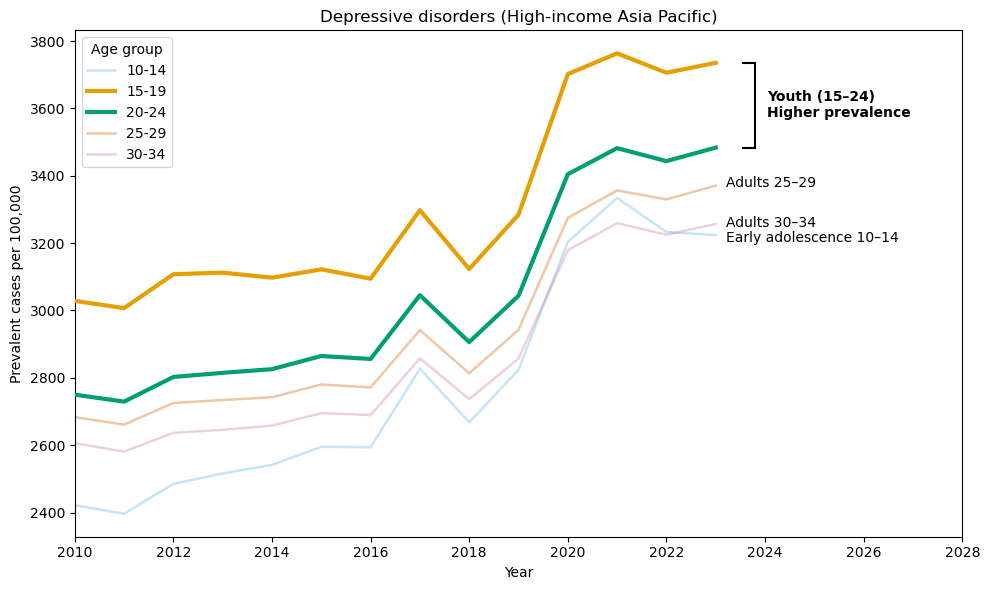

In [15]:
youth = {"15-19", "20-24"}
adults = {"25-29", "30-34", "10-14"}

plt.figure(figsize=(10, 6))

# Okabe-Ito palette so that plot is colour blind friendly
colours = {
    "10-14": "#56B4E9",  # sky blue
    "15-19": "#E69F00",  # orange
    "20-24": "#009E73",  # teal green
    "25-29": "#D55E00",  # vermillion
    "30-34": "#CC79A7",  # pink
}

# plot lines
for age_group, g in agg.groupby("age_group"):
    g = g.sort_values("Year")

    if age_group in youth:
        lw, a, z = 3.0, 1.0, 3
    else:
        lw, a, z = 1.8, 0.35, 1

    plt.plot(
    g["Year"], g["Value"],
    label=age_group,
    linewidth=lw,
    alpha=a,
    zorder=z,
    color=colours[age_group])

last_year = int(agg["Year"].max())

plt.xlim(int(agg["Year"].min()), last_year + 5)

# bracket to annotate the two youth lines at the last year
y_1519 = float(agg[(agg["age_group"] == "15-19") & (agg["Year"] == last_year)]["Value"].iloc[0])
y_2024 = float(agg[(agg["age_group"] == "20-24") & (agg["Year"] == last_year)]["Value"].iloc[0])

y_top = max(y_1519, y_2024)
y_bottom = min(y_1519, y_2024)

x_bracket = last_year + 0.8  # place bracket in the extra whitespace

# plot the bracket
plt.plot([x_bracket, x_bracket], [y_bottom, y_top], color="black", lw=1.5)

tick = 0.25
plt.plot([x_bracket, x_bracket - tick], [y_top, y_top], color="black", lw=1.5)
plt.plot([x_bracket, x_bracket - tick], [y_bottom, y_bottom], color="black", lw=1.5)

# label for the bracket
plt.text(
    x_bracket + 0.25,
    (y_top + y_bottom) / 2,
    "Youth (15–24)\nHigher prevalence",
    fontsize=10,
    weight="bold",
    va="center"
)

# label other lines at the end
def label_line(age, text=None, dx=0.2, dy=0):
    g = agg[agg["age_group"] == age].sort_values("Year")
    y_last = float(g.loc[g["Year"] == last_year, "Value"].iloc[0])
    plt.text(last_year + dx, y_last + dy, text or age, fontsize=10, va="center")

label_line("25-29", "Adults 25–29", dy=9)
label_line("30-34", "Adults 30–34", dy=3)
label_line("10-14", "Early adolescence 10–14", dy=-10)

plt.xlabel("Year")
plt.ylabel("Prevalent cases per 100,000")
plt.title("Depressive disorders (High-income Asia Pacific)")
plt.legend(title="Age group")
plt.tight_layout()
#save plot
#plt.savefig("plot1_youth_depression_gbd.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
tense_data = [
    ("No symptoms", 49.99, 38.96, 11.04),
    ("Depressed mood", 42.74, 46.40, 10.86),
    ("Anhedonia", 26.51, 61.83, 11.67),
    ("Appetite change", 40.33, 50.23, 9.44),
    ("Sleep issues", 46.19, 43.03, 10.78),
    ("Psychomotor alteration", 40.55, 47.81, 11.64),
    ("Fatigue", 39.37, 48.04, 12.59),
    ("Worthlessness", 36.32, 52.13, 11.55),
    ("Cognitive issues", 31.31, 55.98, 12.71),
    ("Suicidal thoughts", 30.55, 57.44, 12.01),
]
df_tense = pd.DataFrame(tense_data, columns=["Symptom", "Past", "Present", "Future"])


pronoun_data = [
    ("No symptoms", 51.84, 5.21, 8.41, 30.37, 4.16),
    ("Depressed mood", 63.52, 3.84, 6.11, 22.43, 4.09),
    ("Anhedonia", 69.86, 1.69, 6.57, 19.18, 2.69),
    ("Appetite change", 68.98, 1.17, 5.38, 19.95, 4.52),
    ("Sleep issues", 65.23, 2.53, 7.29, 21.11, 3.84),
    ("Psychomotor alteration", 64.60, 2.48, 7.13, 22.23, 3.56),
    ("Fatigue", 63.01, 4.36, 7.79, 21.25, 3.58),
    ("Worthlessness", 67.50, 2.61, 6.09, 20.94, 2.85),
    ("Cognitive issues", 68.30, 1.66, 3.32, 24.23, 2.49),
    ("Suicidal thoughts", 66.84, 1.21, 6.21, 22.69, 3.05),
]
df_pronoun = pd.DataFrame(pronoun_data, columns=["Symptom", "FPS", "FPP", "SP", "TPS", "TPP"])

OKABE_ITO = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "teal green": "#009E73",
    "vermillion": "#D55E00",
    "pink": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#009E73",
    "black": "#000000"
}

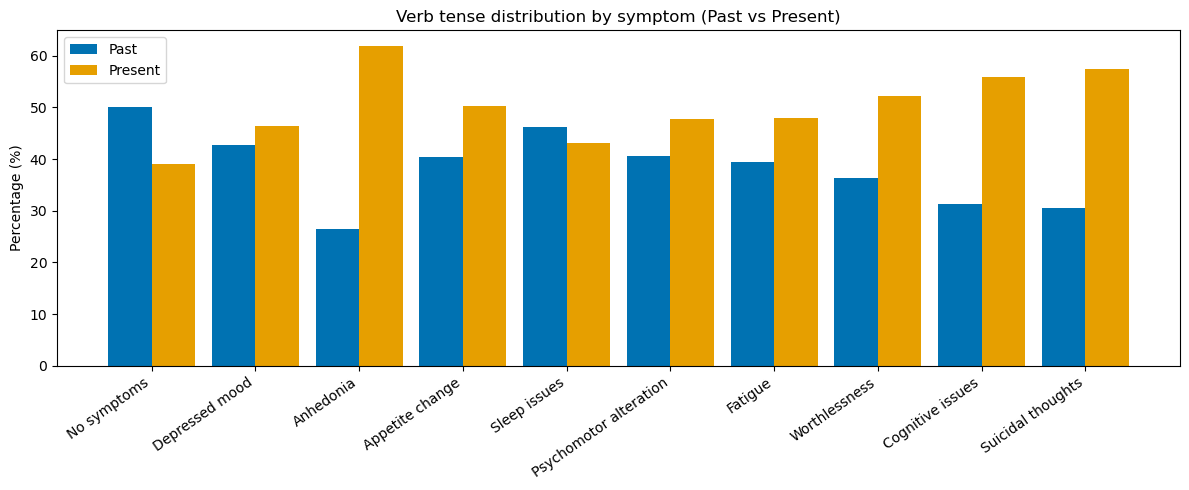

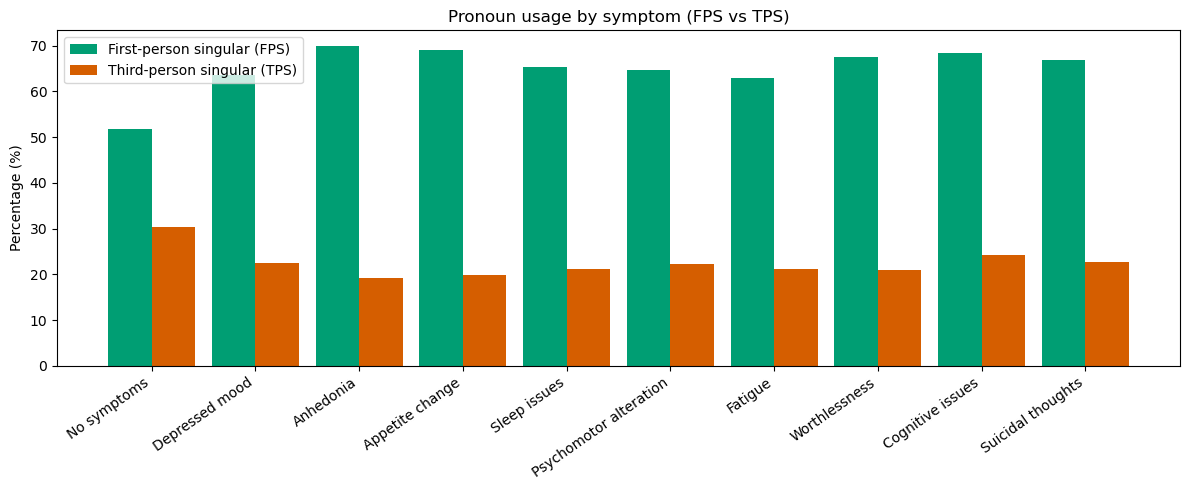

In [33]:
order = df_tense["Symptom"].tolist()
df_tense = df_tense.set_index("Symptom").loc[order].reset_index()

x = range(len(df_tense))
bar_w = 0.42

plt.figure(figsize=(12, 5))
plt.bar(
    [i - bar_w/2 for i in x],
    df_tense["Past"],
    width=bar_w,
    label="Past",
    color=OKABE_ITO["blue"]
)

plt.bar(
    [i + bar_w/2 for i in x],
    df_tense["Present"],
    width=bar_w,
    label="Present",
    color=OKABE_ITO["orange"]
)

plt.xticks(list(x), df_tense["Symptom"], rotation=35, ha="right")
plt.ylabel("Percentage (%)")
plt.title("Verb tense distribution by symptom (Past vs Present)")
plt.legend()
plt.tight_layout()
#plt.savefig("plot2A_verb_tense.png", dpi=300, bbox_inches="tight")
plt.show()


df_pronoun = df_pronoun.set_index("Symptom").loc[order].reset_index()

x = range(len(df_pronoun))

plt.figure(figsize=(12, 5))
plt.bar(
    [i - bar_w/2 for i in x],
    df_pronoun["FPS"],
    width=bar_w,
    label="First-person singular (FPS)",
    color=OKABE_ITO["teal green"]
)

plt.bar(
    [i + bar_w/2 for i in x],
    df_pronoun["TPS"],
    width=bar_w,
    label="Third-person singular (TPS)",
    color=OKABE_ITO["vermillion"]
)

plt.xticks(list(x), df_pronoun["Symptom"], rotation=35, ha="right")
plt.ylabel("Percentage (%)")
plt.title("Pronoun usage by symptom (FPS vs TPS)")
plt.legend()
plt.tight_layout()
#plt.savefig("plot2B_pronouns.png", dpi=300, bbox_inches="tight")
plt.show()

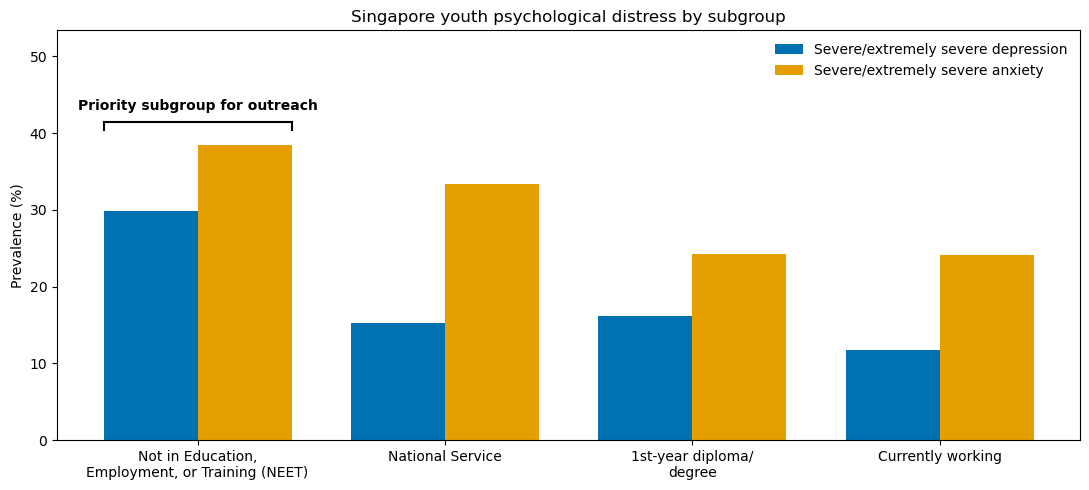

In [71]:
neet_label = "Not in Education,\nEmployment, or Training (NEET)"

data = [
    {"Group": "National Service", "Depression": 15.3, "Anxiety": 33.4},
    {"Group": "1st-year diploma/\ndegree", "Depression": 16.2, "Anxiety": 24.3},
    {"Group": neet_label, "Depression": 29.8, "Anxiety": 38.4},
    {"Group": "Currently working", "Depression": 11.8, "Anxiety": 24.1},
]
df = pd.DataFrame(data)

# Reorder to put NEET first
order = [
    neet_label,
    "National Service",
    "1st-year diploma/\ndegree",
    "Currently working"
]
df = df.set_index("Group").loc[order].reset_index()

# Plot settings
x = np.arange(len(df))
bar_w = 0.38

plt.figure(figsize=(11, 5))

plt.bar(
    x - bar_w/2,
    df["Depression"],
    width=bar_w,
    label="Severe/extremely severe depression",
    color=OKABE_ITO["blue"]
)
plt.bar(
    x + bar_w/2,
    df["Anxiety"],
    width=bar_w,
    label="Severe/extremely severe anxiety",
    color=OKABE_ITO["orange"]
)


neet_pos = int(df.index[df["Group"] == neet_label][0])  # 0..3
neet_y = float(max(df.loc[neet_pos, "Depression"], df.loc[neet_pos, "Anxiety"]))

# --- Bracket highlighting NEET group ---
neet_idx = df.index[df["Group"] == neet_label][0]

# x positions of the two NEET bars
x_left = neet_idx - bar_w
x_right = neet_idx + bar_w

# height of the bracket (a bit above the tallest bar)
neet_y = max(df.loc[neet_idx, ["Depression", "Anxiety"]])
bracket_y = neet_y + 3

# draw bracket
plt.plot([x_left, x_right], [bracket_y, bracket_y], color="black", lw=1.5)
plt.plot([x_left, x_left], [bracket_y - 1, bracket_y], color="black", lw=1.5)
plt.plot([x_right, x_right], [bracket_y - 1, bracket_y], color="black", lw=1.5)

# bracket label
plt.text(
    neet_idx,
    bracket_y + 1.2,
    "Priority subgroup for outreach",
    ha="center",
    va="bottom",
    fontsize=10,
    weight="bold"
)

plt.xticks(x, df["Group"])
plt.ylabel("Prevalence (%)")
plt.title("Singapore youth psychological distress by subgroup")
plt.ylim(0, max(df["Anxiety"].max(), df["Depression"].max()) + 15)
plt.legend(frameon=False)

plt.tight_layout()
#plt.savefig("plot3_nymhs_neet_actionable.png", dpi=300, bbox_inches="tight")
plt.show()